## Task 1: Data Loading & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
print("Current Folder:")
print(os.getcwd())

print("\nFiles Available:")
print(os.listdir())

Current Folder:
C:\Users\archa\SalesForecasting_Archana

Files Available:
['.ipynb_checkpoints', 'analysis.ipynb', 'train.csv.zip', 'vgsales.csv.zip']


In [7]:
train = pd.read_csv("train.csv.zip")
vgsales = pd.read_csv("vgsales.csv.zip")

print("Train Dataset Shape :", train.shape)
print("Video Game Dataset Shape :", vgsales.shape)

Train Dataset Shape : (9800, 18)
Video Game Dataset Shape : (16598, 11)


In [8]:
train.head()
vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [10]:
print(train.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [11]:
print("Duplicate Rows:", train.duplicated().sum())

Duplicate Rows: 0


In [12]:
train.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [13]:
print(train.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [14]:
for col in train.columns:
    print(f"{col}: {train[col].nunique()}")

Row ID: 9800
Order ID: 4922
Order Date: 1230
Ship Date: 1326
Ship Mode: 4
Customer ID: 793
Customer Name: 793
Segment: 3
Country: 1
City: 529
State: 49
Postal Code: 626
Region: 4
Product ID: 1861
Category: 3
Sub-Category: 17
Product Name: 1849
Sales: 5757


In [16]:
# Convert Order Date and Ship Date into datetime format
train["Order Date"] = pd.to_datetime(
    train["Order Date"],
    dayfirst=True
)

train["Ship Date"] = pd.to_datetime(
    train["Ship Date"],
    dayfirst=True
)

print(train[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [17]:
# Create new date-related features
train["Year"] = train["Order Date"].dt.year
train["Month"] = train["Order Date"].dt.month
train["Month_Name"] = train["Order Date"].dt.month_name()
train["Quarter"] = train["Order Date"].dt.quarter
train["Week"] = train["Order Date"].dt.isocalendar().week
train["Day"] = train["Order Date"].dt.day
train["Day_Name"] = train["Order Date"].dt.day_name()

train.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Quarter,Week,Day,Day_Name
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday


In [18]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

train["Season"] = train["Month"].apply(get_season)

train[["Order Date", "Month", "Season"]].head()

,Order Date,Month,Season
0,2017-11-08,11,Autumn
1,2017-11-08,11,Autumn
2,2017-06-12,6,Summer
3,2016-10-11,10,Autumn
4,2016-10-11,10,Autumn


In [19]:
monthly_sales = train.groupby("Month_Name")["Sales"].sum()

print(monthly_sales)

Month_Name
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64


In [20]:
yearly_sales = train.groupby("Year")["Sales"].sum()

print(yearly_sales)

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


In [21]:
category_sales = train.groupby("Category")["Sales"].sum()

print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


In [22]:
region_sales = train.groupby("Region")["Sales"].sum()

print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


In [23]:
top_states = (
    train.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_states)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


In [24]:
top_products = (
    train.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [25]:
print("Dataset Shape:", train.shape)
train.head()

Dataset Shape: (9800, 26)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Quarter,Week,Day,Day_Name,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday,Autumn


## Task 2: Exploratory Data Analysis (EDA)

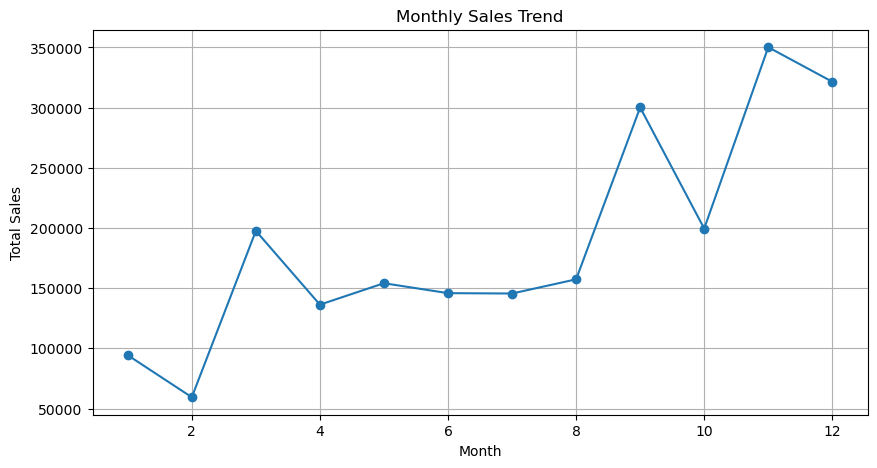

In [26]:
monthly_sales = train.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

plt.savefig("monthly_sales_trend.png")
plt.show()

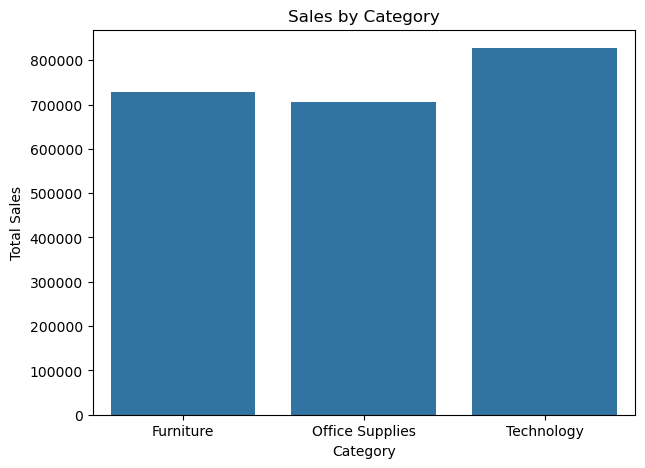

In [27]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=train.groupby("Category")["Sales"].sum().index,
    y=train.groupby("Category")["Sales"].sum().values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("sales_by_category.png")
plt.show()

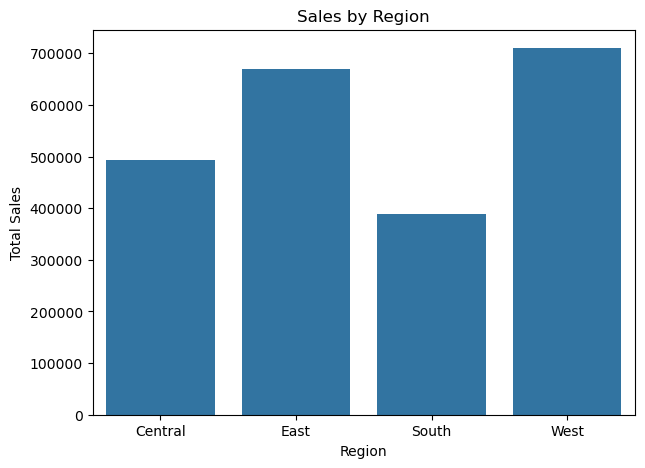

In [28]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=train.groupby("Region")["Sales"].sum().index,
    y=train.groupby("Region")["Sales"].sum().values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.savefig("sales_by_region.png")
plt.show()

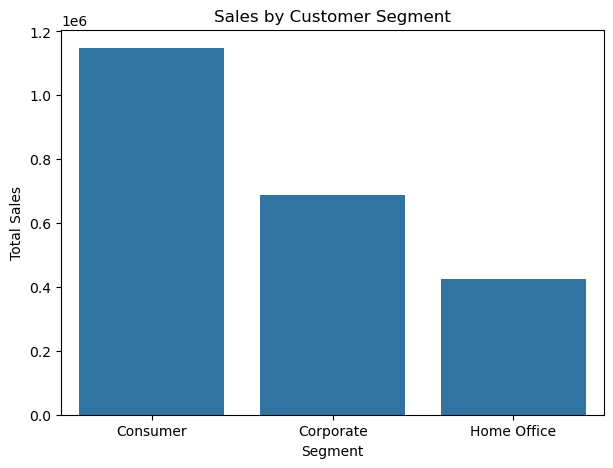

In [29]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=train.groupby("Segment")["Sales"].sum().index,
    y=train.groupby("Segment")["Sales"].sum().values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.savefig("sales_by_segment.png")
plt.show()

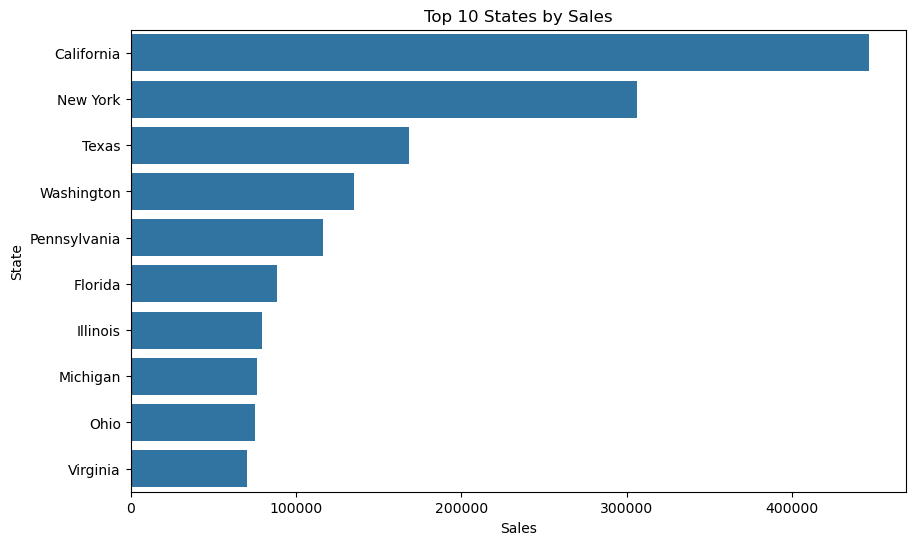

In [30]:
top_states = train.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.savefig("top10_states.png")
plt.show()

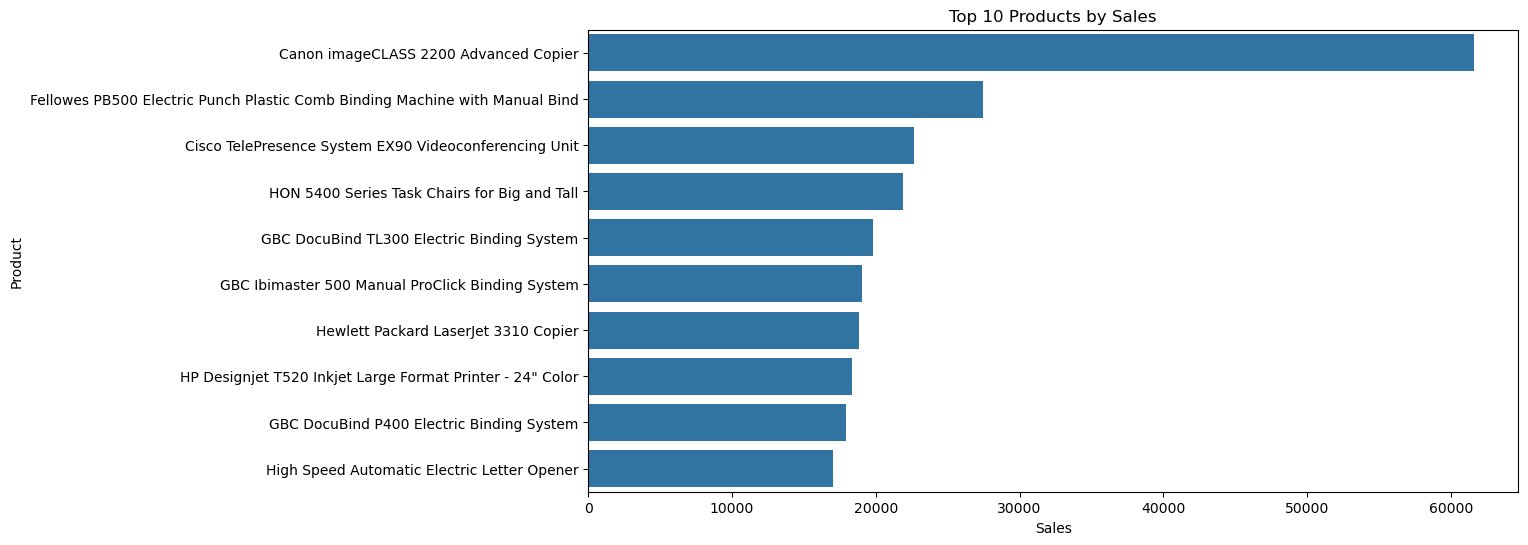

In [31]:
top_products = train.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.savefig("top10_products.png")
plt.show()

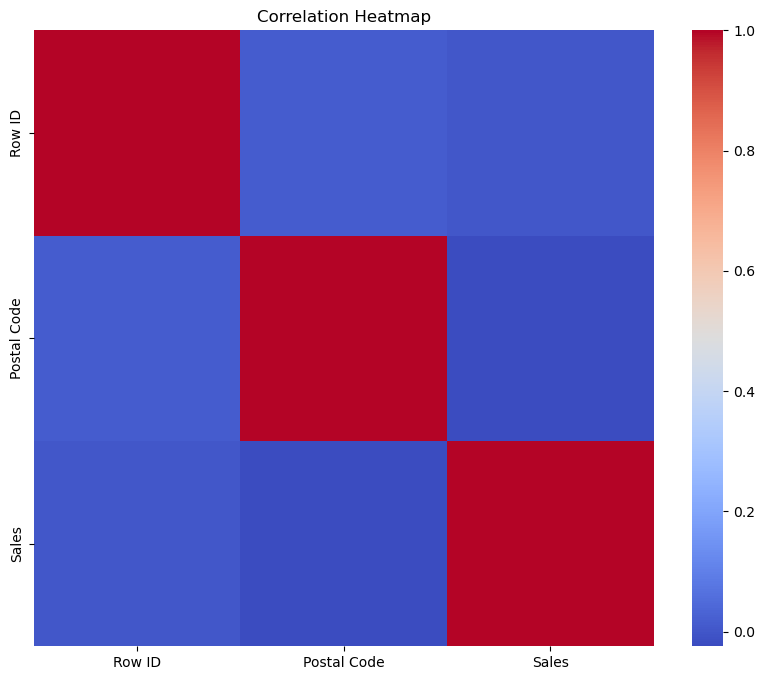

In [32]:
plt.figure(figsize=(10,8))

numeric = train.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()

In [34]:
# Create monthly sales data
monthly_sales = (
    train.groupby("Order Date")["Sales"]
    .sum()
    .resample("ME")
    .sum()
)

monthly_sales = monthly_sales.to_frame()

print(monthly_sales.head())

                Sales
Order Date           
2015-01-31  14205.707
2015-02-28   4519.892
2015-03-31  55205.797
2015-04-30  27906.855
2015-05-31  23644.303


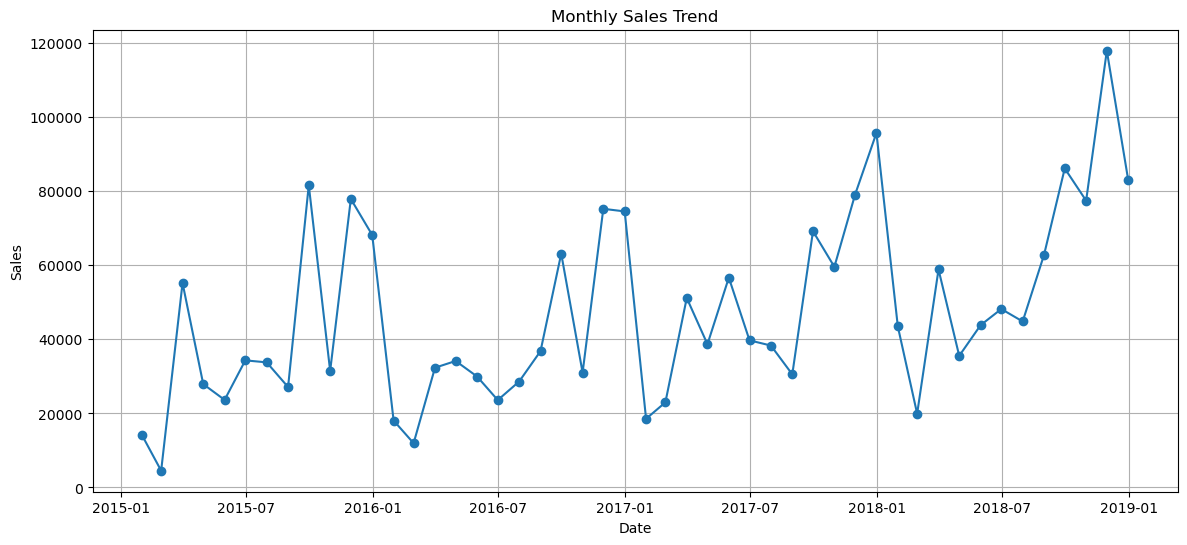

In [35]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.savefig("monthly_sales_trend.png")

plt.show()

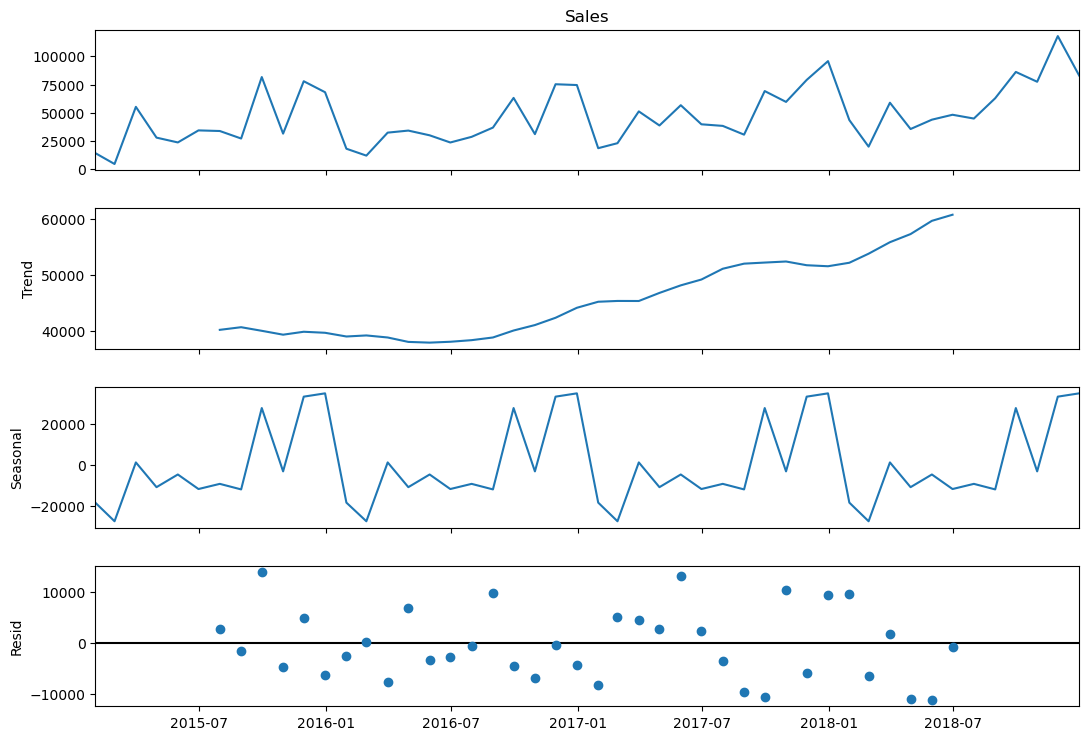

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12,8)

plt.savefig("time_series_decomposition.png")

plt.show()

In [37]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430768
p-value : 0.00027791039276670677
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


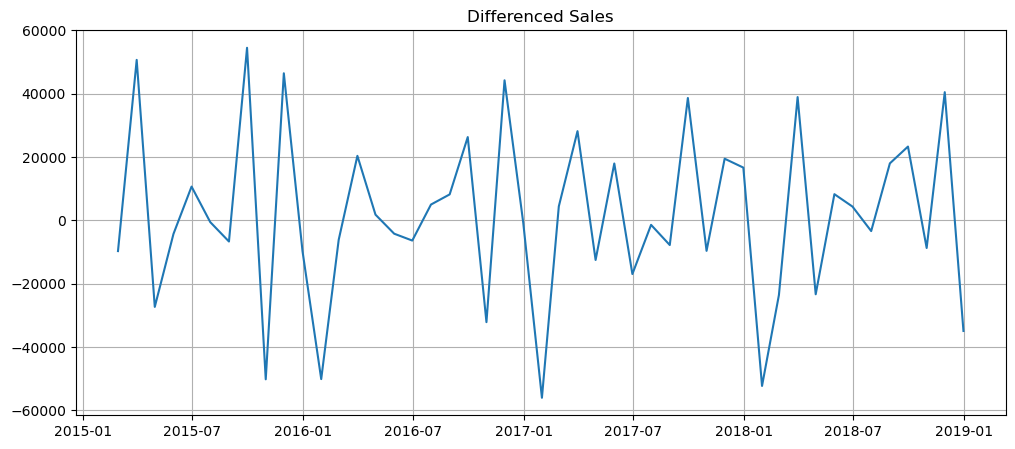

In [38]:
monthly_sales_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales_diff)

plt.title("Differenced Sales")
plt.grid(True)

plt.savefig("differenced_sales.png")

plt.show()

In [39]:
result = adfuller(monthly_sales_diff["Sales"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

ADF Statistic : -8.727061830353259
p-value : 3.2669175472798525e-14


In [40]:
train_size = int(len(monthly_sales) * 0.8)

train_ts = monthly_sales.iloc[:train_size]
test_ts = monthly_sales.iloc[train_size:]

print(train_ts.shape)
print(test_ts.shape)

(38, 1)
(10, 1)


In [41]:
pip install prophet xgboost statsmodels

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 5.2 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.1 MB 6.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/12.1 MB 6.6 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/12.1 MB 6.2 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.1 MB 6.4 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.1 MB 6.5 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 6.5 MB/s eta 0:00:01
   -------------------------------- ------- 10.0/12.1 MB 6.5 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.1 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 6.0 MB/s  0:00:02
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------- ----- 1.3/1.5 MB 8.8 MB/s eta 0:00:01
   ------------

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train_ts["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

print(sarima_model.summary())

C:\Users\archa\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -272.600
Date:                            Sun, 12 Jul 2026   AIC                            555.200
Time:                                    10:18:31   BIC                            561.294
Sample:                                01-31-2015   HQIC                           556.890
                                     - 02-28-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5934      0.234      2.539      0.011       0.135       1.051
ma.L1         -0.8931      0.195   

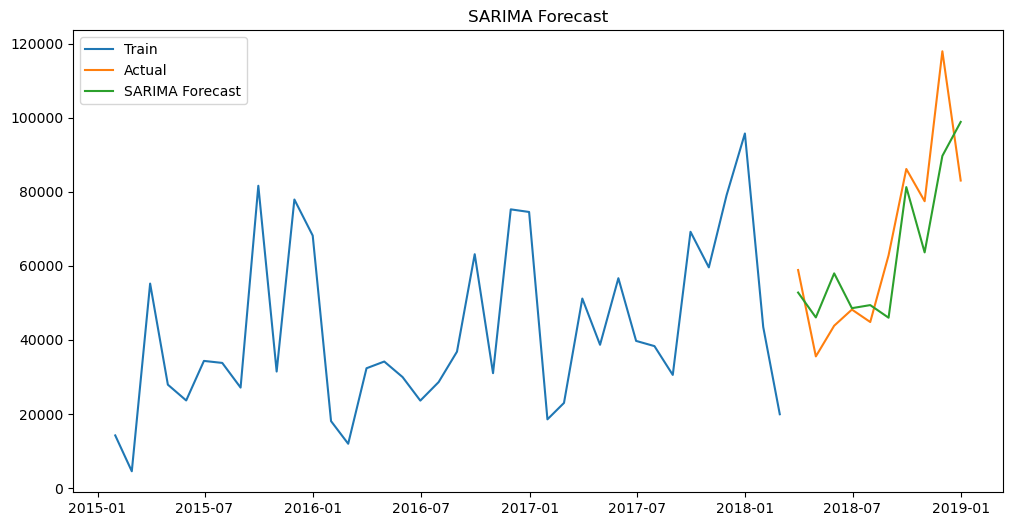

In [43]:
sarima_forecast = sarima_model.forecast(len(test_ts))

plt.figure(figsize=(12,6))

plt.plot(train_ts.index, train_ts["Sales"], label="Train")
plt.plot(test_ts.index, test_ts["Sales"], label="Actual")
plt.plot(test_ts.index, sarima_forecast, label="SARIMA Forecast")

plt.legend()

plt.title("SARIMA Forecast")

plt.savefig("sarima_forecast.png")

plt.show()

10:20:48 - cmdstanpy - INFO - Chain [1] start processing
10:20:48 - cmdstanpy - INFO - Chain [1] done processing


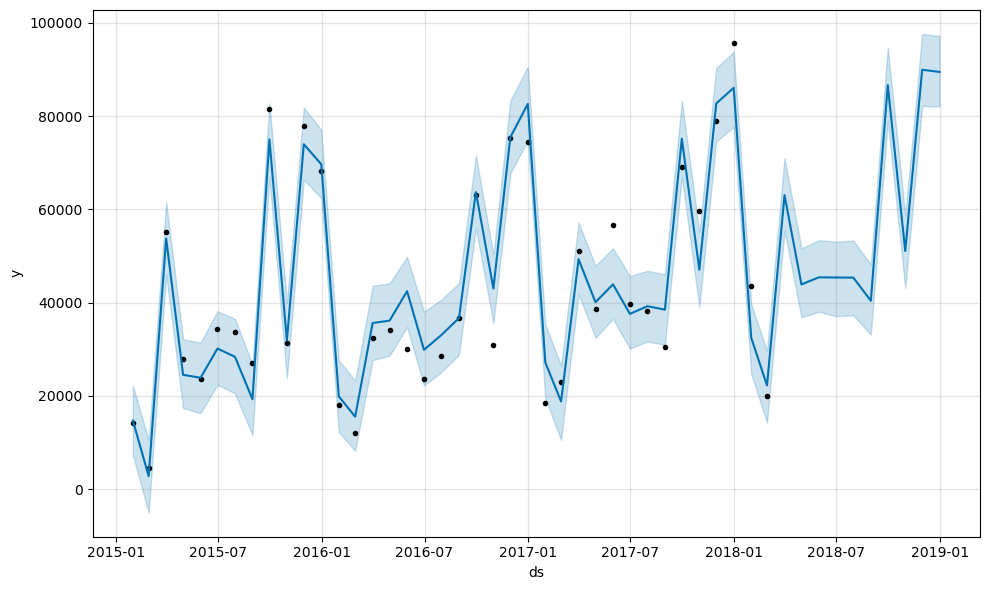

In [45]:
from prophet import Prophet

prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds","y"]

train_prophet = prophet_df.iloc[:38]
test_prophet = prophet_df.iloc[38:]

model = Prophet()

model.fit(train_prophet)

future = model.make_future_dataframe(periods=10, freq="ME")

forecast = model.predict(future)

model.plot(forecast)

plt.savefig("prophet_forecast.png")

plt.show()

In [46]:
from xgboost import XGBRegressor

monthly_sales_ml = monthly_sales.copy()

monthly_sales_ml["Month"] = monthly_sales_ml.index.month
monthly_sales_ml["Year"] = monthly_sales_ml.index.year

X = monthly_sales_ml[["Month","Year"]]

y = monthly_sales_ml["Sales"]

X_train = X.iloc[:38]
X_test = X.iloc[38:]

y_train = y.iloc[:38]
y_test = y.iloc[38:]

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train,y_train)

pred = xgb.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

print("SARIMA Performance")

mae = mean_absolute_error(test_ts["Sales"], sarima_forecast)
rmse = np.sqrt(mean_squared_error(test_ts["Sales"], sarima_forecast))
mape = mean_absolute_percentage_error(test_ts["Sales"], sarima_forecast)

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

SARIMA Performance
MAE : 11532.900688792699
RMSE : 13843.49324767624
MAPE : 0.17652653484745562


In [49]:
print("XGBoost Performance")

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = mean_absolute_percentage_error(y_test, pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

XGBoost Performance
MAE : 15730.311060000002
RMSE : 19085.171774408456
MAPE : 0.22605637005971024


In [50]:
future_forecast = sarima_model.forecast(steps=3)

print(future_forecast)

2018-03-31    52784.841908
2018-04-30    46067.089470
2018-05-31    57964.457730
Freq: ME, Name: predicted_mean, dtype: float64


In [51]:
forecast_df = pd.DataFrame({
    "Forecast":future_forecast
})

forecast_df.to_csv("future_sales_forecast.csv")

forecast_df

,Forecast
2018-03-31,52784.841908
2018-04-30,46067.089470
2018-05-31,57964.457730


## Part 3 – Anomaly Detection

In [52]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

train["Anomaly"] = iso.fit_predict(train[["Sales"]])

train["Anomaly"] = train["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

train.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Quarter,Week,Day,Day_Name,Season,Anomaly
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday,Autumn,Normal
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday,Autumn,Normal
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday,Summer,Normal
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday,Autumn,Normal
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday,Autumn,Normal


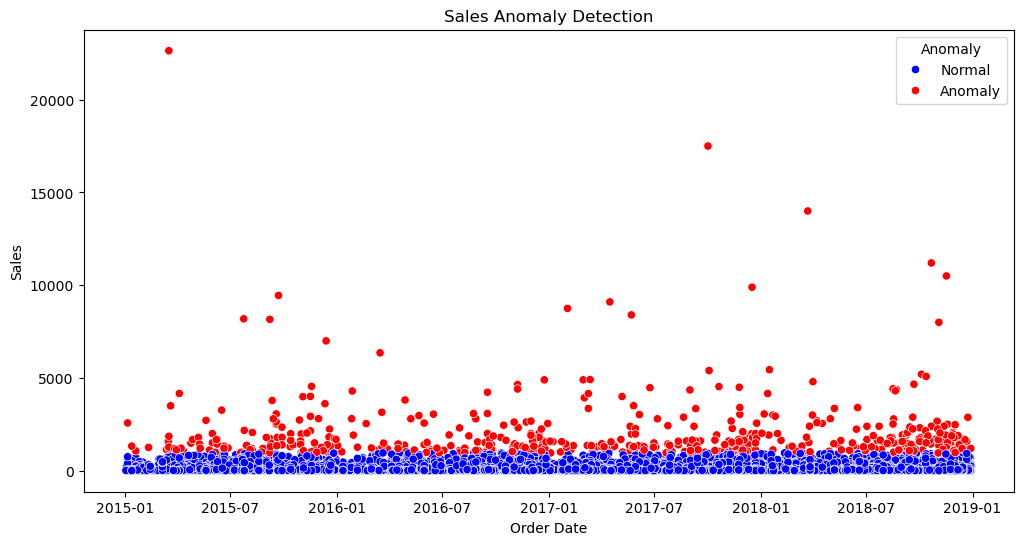

In [53]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=train,
    x="Order Date",
    y="Sales",
    hue="Anomaly",
    palette={"Normal":"blue","Anomaly":"red"}
)

plt.title("Sales Anomaly Detection")

plt.savefig("sales_anomaly.png")

plt.show()

In [54]:
print(train["Anomaly"].value_counts())

Anomaly
Normal     9310
Anomaly     490
Name: count, dtype: int64


In [55]:
from scipy.stats import zscore

train["Z_Score"] = zscore(train["Sales"])

anomalies = train[
    abs(train["Z_Score"]) > 3
]

print(anomalies.shape)

anomalies.head()

(123, 28)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Quarter,Week,Day,Day_Name,Season,Anomaly,Z_Score
27,28,US-2016-150630,2016-09-17,2016-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,Pennsylvania,19140.0,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430,2016,9,September,3,37,17,Saturday,Autumn,Anomaly,4.552458
165,166,CA-2015-139892,2015-09-08,2015-09-12,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,Texas,78207.0,Central,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,8159.952,2015,9,September,3,37,8,Tuesday,Autumn,Anomaly,12.653896
251,252,CA-2017-145625,2017-09-11,2017-09-17,Standard Class,KC-16540,Kelly Collister,Consumer,United States,San Diego,California,92037.0,West,TEC-AC-10003832,Technology,Accessories,Logitech P710e Mobile Speakerphone,3347.370,2017,9,September,3,37,11,Monday,Autumn,Anomaly,4.973671
262,263,US-2015-106992,2015-09-19,2015-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,Texas,77036.0,Central,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,3059.982,2015,9,September,3,38,19,Saturday,Autumn,Anomaly,4.515038
263,264,US-2015-106992,2015-09-19,2015-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,Texas,77036.0,Central,TEC-MA-10003353,Technology,Machines,Xerox WorkCentre 6505DN Laser Multifunction Pr...,2519.958,2015,9,September,3,38,19,Saturday,Autumn,Anomaly,3.653234


In [56]:
anomalies.to_csv("sales_anomalies.csv", index=False)

print("Anomaly file saved successfully.")

Anomaly file saved successfully.


## Part 4 – Customer Demand Clustering (K-Means)

In [57]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [68]:
cluster_data = train[["Sales", "Postal Code"]].copy()

# Fill missing Postal Code values
cluster_data["Postal Code"] = cluster_data["Postal Code"].fillna(
    cluster_data["Postal Code"].median()
)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

In [69]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

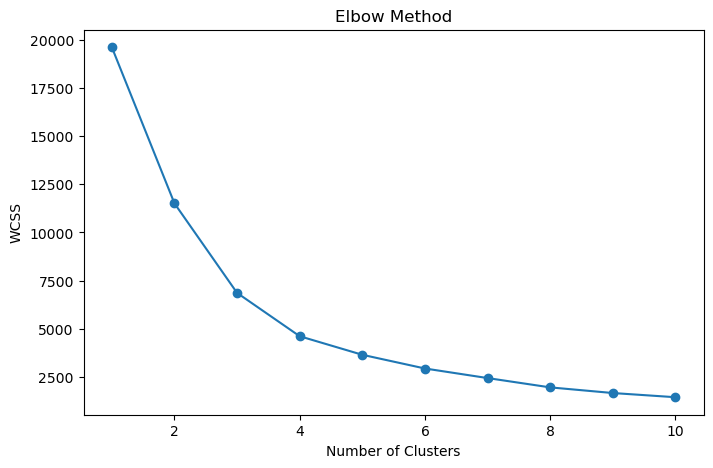

In [70]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.savefig("elbow_method.png")

plt.show()

In [72]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

train["Cluster"] = kmeans.fit_predict(scaled_data)

train.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Quarter,Week,Day,Day_Name,Season,Anomaly,Z_Score,Cluster
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday,Autumn,Normal,0.049776,1
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday,Autumn,Normal,0.799801,1
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday,Summer,Normal,-0.344944,2
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday,Autumn,Normal,1.159887,1
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday,Autumn,Normal,-0.332580,1


In [73]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = train["Cluster"]

pca_df.head()

,PC1,PC2,Cluster
0,0.319096,-0.248701,1
1,0.849443,0.281646,1
2,-1.011475,0.523650,2
3,1.305208,0.335120,1
4,0.249875,-0.720213,1


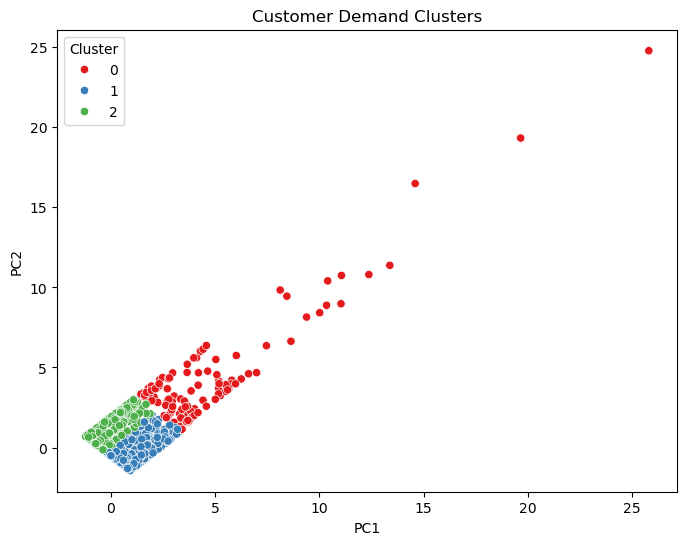

In [74]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Demand Clusters")

plt.savefig("customer_clusters.png")

plt.show()

In [75]:
print(train["Cluster"].value_counts())

Cluster
2    4979
1    4701
0     120
Name: count, dtype: int64


In [76]:
train.to_csv(
    "sales_with_clusters.csv",
    index=False
)

print("Cluster file saved successfully.")

Cluster file saved successfully.
